In [2]:
from pathlib import Path
import json

from IPython.display import display, Markdown

from resources.imports import *
import torch

from resources.MLdata import DATA
from resources.MLmodels import MODEL
from resources.MLfunc import plot_predictions
from resources.MLmetrics import (
    postprocess_resolve_artifacts,
    postprocess_list_runs,
    postprocess_load_artifacts,
    postprocess_load_data,
    postprocess_available_evaluations,
    postprocess_attach_results,
    postprocess_build_diagnostics,
    postprocess_output_dir,
    postprocess_save_open_figures,
    print_curve_diagnostics,
    plot_curve_diagnostics,
    plot_prediction_error_curves,
    plot_curve_correlation_matrix,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [ ]:
%load_ext autoreload
%autoreload 2

# ML Post-Processing

## 1. User Configuration

Paste a specific run directory, model `.json`, model `.mdl`, regular HPO directory, or best-model HPO directory into `RUN_PATH`. If `RUN_PATH = None`, the notebook lists recent runs under `RUN_ROOT` and selects `RUN_INDEX`.

In [3]:
RUN_ROOT = Path(r"Z:/p2")
RUN_PATH = r"Z:\\p2\\UT\\MLP\\HPO\\HPC-MLP_full_hOpt"
RUN_INDEX = 0

PREFER_HPO_BEST = True
USE_SAVED_RESULTS_ONLY = True
LOAD_DATA = True
LOAD_MODEL = True
DEVICE = "cpu"

DATA_PATH_OVERRIDE = "auto"

RECOMPUTE_MISSING_DIAGNOSTICS_FROM_SAVED_PREDICTIONS = True
RECOMPUTE_MISSING_PREDICTIONS_WITH_MODEL = False
RUN_ACTIVATION_DIAGNOSTICS = False

SAVE_FIGURES = True
SAVE_RECOMPUTED_TABLES = True
OVERWRITE_POSTPROCESSING_OUTPUTS = True
POSTPROCESSING_LABEL = None

ACTIVE_MODE = None
ACTIVE_SPLIT = None
ZONE_BOUNDARIES = None

MAX_SAMPLES_PLOT = 64
ERROR_CURVE_SAMPLES = 100
RANDOM_SAMPLE_COUNT = 8
SELECTED_SAMPLE = 0

## 2. Find Recent Runs


In [4]:
recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=25, include_hpo=True)
display(recent_runs)

if RUN_PATH is None:
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")
    RUN_PATH = Path(recent_runs.loc[int(RUN_INDEX), "run_dir"])

print("Selected RUN_PATH:", RUN_PATH)

,run_dir,model_json,model_mdl,results_dir,is_hpo,modified
0,Z:\p2\UT\HPO\HPC-GNN_full_hOpt\GCN,Z:\p2\UT\HPO\HPC-GNN_full_hOpt\GCN\best_model....,Z:\p2\UT\HPO\HPC-GNN_full_hOpt\GCN\best_model.mdl,Z:\p2\UT\HPO\HPC-GNN_full_hOpt\GCN\best_model_...,True,2026-05-14 23:05:48
1,Z:\p2\UT\Transformer\HPO\HPC-TR_full_hOpt,Z:\p2\UT\Transformer\HPO\HPC-TR_full_hOpt\best...,Z:\p2\UT\Transformer\HPO\HPC-TR_full_hOpt\best...,Z:\p2\UT\Transformer\HPO\HPC-TR_full_hOpt\best...,True,2026-05-14 18:55:34
2,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model....,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model.mdl,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...,True,2026-05-14 18:54:56
3,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,Z:\p2\Akash\FCC_disNodes_dN-0.2_data-in_nSims-...,False,2026-05-06 19:54:10


Selected RUN_PATH: Z:\\p2\\UT\\MLP\\HPO\\HPC-MLP_full_hOpt


## 3. Resolve And Load Saved Artifacts

Regular runs should resolve to `results/`. HPO best-model runs should resolve to `best_model_results/` when present.

In [5]:
artifacts = postprocess_resolve_artifacts(
    RUN_PATH,
    run_root=RUN_ROOT,
    prefer_hpo_best=PREFER_HPO_BEST,
)

artifact_rows = []
for key, value in artifacts.items():
    if key == "hpo_candidate_model_jsons":
        artifact_rows.append((key, len(value)))
    elif key != "warnings":
        artifact_rows.append((key, str(value) if value is not None else None))
display(pd.DataFrame(artifact_rows, columns=["artifact", "path_or_value"]))

for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)

loaded = postprocess_load_artifacts(artifacts)
POST_DIR = postprocess_output_dir(artifacts, label=POSTPROCESSING_LABEL, create=True)
print("Post-processing output directory:", POST_DIR)

,artifact,path_or_value
0,input_path,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt
1,run_dir,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt
2,model_json,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model....
3,model_mdl,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model.mdl
4,data_json,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...
5,results_dir,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...
6,metrics_json,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...
7,predictions_npz,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...
8,diagnostics_summary_json,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_...
9,hpo_dir,Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt


Post-processing output directory: Z:\p2\UT\MLP\HPO\HPC-MLP_full_hOpt\best_model_results\postProcessing


## 4. Load DATA And MODEL

The data path is overridden to `RUN_ROOT` by default so HPC-side paths such as `/data/.../p2` can be reopened locally from `Z:/p2`.

In [6]:
DAT = None
if LOAD_DATA and artifacts.get("data_json") is not None:
    try:
        DAT = postprocess_load_data(
            artifacts["data_json"],
            data_path_override=DATA_PATH_OVERRIDE,
            auto_path_root=RUN_ROOT,
        )
        print("Loaded DATA from:", artifacts["data_json"])
    except Exception as exc:
        print("DATA load failed:", repr(exc))

MOD = None
if LOAD_MODEL and artifacts.get("model_json") is not None and DAT is not None:
    try:
        MOD = MODEL.from_json(
            artifacts["model_json"],
            data=DAT,
            load_weights=artifacts.get("model_mdl") is not None,
            model_path=str(artifacts["model_mdl"]) if artifacts.get("model_mdl") is not None else None,
            device=DEVICE,
            scan_matches_on_init=False,
        )
        MOD = postprocess_attach_results(MOD, loaded)
        print("Loaded MODEL from:", artifacts["model_json"])
    except Exception as exc:
        print("MODEL load failed:", repr(exc))
elif LOAD_MODEL:
    print("MODEL was not loaded because a model JSON or DATA object is missing.")

DATA load failed: FileNotFoundError(2, 'No such file or directory')
MODEL was not loaded because a model JSON or DATA object is missing.


## 5. Run Overview And HPO Files

In [7]:
descriptor = loaded.get("descriptor") or {}
data_descriptor = loaded.get("data_descriptor") or {}
metrics = loaded.get("metrics") or {}
hpo = loaded.get("hpo") or {}

if descriptor:
    display(Markdown("### Model Descriptor"))
    display(pd.json_normalize(descriptor, sep=".").T.rename(columns={0: "value"}))
else:
    print("No model descriptor JSON was loaded.")

if data_descriptor:
    display(Markdown("### Data Descriptor"))
    display(pd.json_normalize(data_descriptor, sep=".").T.rename(columns={0: "value"}))

if hpo:
    display(Markdown("### HPO Artifacts"))
    for key, value in hpo.items():
        display(Markdown(f"#### {key}"))
        display(pd.json_normalize(value, sep=".").T.rename(columns={0: "value"}))
else:
    print("No HPO files were found for this run.")

### Model Descriptor

,value
coarse_setup_hash,61caffed239e7b113c1e2694a23e0881f76096a1
descriptor_created_at,2026-05-14T15:24:15
exact_setup_hash,69739c2a7e66024d3d2e9319a14f4ad8a28b82af
name,best_model
path,/gpfs/scratch/exy053/9981582/mlruns/UT/FCC_dis...
...,...
run_layout.model,MLP
run_layout.results_dir,/gpfs/scratch/exy053/9981582/mlruns/UT/FCC_dis...
run_layout.root,/gpfs/scratch/exy053/9981582/mlruns
run_layout.run_descriptor,HPC-MLP_full_hOpt


### Data Descriptor

,value
class,DATA
version,1
data_config.LAT,FCC
data_config.dN,0.2
data_config.d_data,in
data_config.dis,disNodes
data_config.freq,False
data_config.geom_feats,"[False, False]"
data_config.load,True
data_config.load_split,False


### HPO Artifacts

#### best_params

,value
mlp_act,relu
mlp_norm,None
mlp_dropout,0.243214
mlp_head_dropout,0.174379
mlp_depth,5
mlp_width,512
mlp_block,res
mlp_head_norm,layer
loss_family,mse
optimizer,adamw


#### best_trial_user_attrs

,value
best_model_checkpoint,/gpfs/scratch/exy053/9981582/mlruns/UT/FCC_dis...
task_scores,[0.2939259126380738]
typ,mlp
loss_params.family,mse
model_params.in_size,1444
model_params.out_size,201
model_params.h_size,"[512, 512, 512, 512, 512]"
model_params.act,relu
model_params.block,res
model_params.norm,None


## 6. Saved Metrics And Available Evaluations

In [ ]:
if metrics:
    display(Markdown("### Full metrics.json"))
    display(pd.json_normalize(metrics, sep=".").T.rename(columns={0: "value"}))

    scalar_metrics = {k: v for k, v in metrics.items() if isinstance(v, (str, int, float, bool)) or v is None}
    if scalar_metrics:
        display(Markdown("### Scalar Metrics"))
        display(pd.DataFrame(sorted(scalar_metrics.items()), columns=["metric", "value"]))
else:
    print("No metrics.json was found.")

available_evals = postprocess_available_evaluations(loaded)
curve_eval_columns = [
    "mode",
    "split",
    "outputs",
    "truth",
    "sample_metrics",
    "point_metrics",
    "zone_metrics",
]
available_curve_evals = available_evals[[col for col in curve_eval_columns if col in available_evals.columns]]
display(Markdown("### Available Curve Predictions / Diagnostic Tables"))
display(available_curve_evals)

if ACTIVE_SPLIT is None:
    ACTIVE_SPLIT = metrics.get("evaluation_split", None)
if (ACTIVE_MODE is None or ACTIVE_SPLIT is None) and not available_evals.empty:
    if ACTIVE_MODE is None:
        ACTIVE_MODE = available_evals.iloc[0]["mode"]
    if ACTIVE_SPLIT is None:
        ACTIVE_SPLIT = available_evals.iloc[0]["split"]

print("ACTIVE_MODE:", ACTIVE_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)

## 7. Build In-Memory Diagnostics

This section may rebuild diagnostics from saved `predictions.npz` arrays. It does not run the neural network unless you explicitly enable the recompute-predictions section later.

In [9]:
diagnostics = {}
recomputed_table_paths = []

for _, row in available_evals.iterrows():
    mode = str(row["mode"]).upper()
    split = str(row["split"]).lower()
    saved_summary = (loaded.get("diagnostics_summary") or {}).get(mode, {})
    zone_cfg = ZONE_BOUNDARIES
    if zone_cfg is None and isinstance(saved_summary, dict):
        zone_cfg = saved_summary.get("zone_boundaries", None)

    diag = postprocess_build_diagnostics(
        DAT,
        loaded,
        mode=mode,
        split=split,
        zone_boundaries=zone_cfg,
        prefer_saved_tables=True,
        recompute_from_predictions=RECOMPUTE_MISSING_DIAGNOSTICS_FROM_SAVED_PREDICTIONS,
    )
    if diag is None:
        print(f"No prediction arrays available to build diagnostics for {mode} {split}.")
        continue

    diagnostics[(mode, split)] = diag
    if MOD is not None:
        setattr(MOD, f"{mode}_{split}_diagnostics", diag)
        if split == "test":
            setattr(MOD, f"{mode}_diagnostics", diag)
            setattr(MOD, f"{mode}_prediction_summary", diag.get("summary"))

    print_curve_diagnostics(diag, label=f"{mode} {split}")

    if SAVE_RECOMPUTED_TABLES:
        for table_key in ["sample_metrics", "point_metrics", "zone_metrics"]:
            saved_key = f"{mode}_{split}_{table_key}"
            table = diag.get(table_key)
            was_saved = saved_key in loaded.get("diagnostic_tables", {})
            if hasattr(table, "to_csv") and not was_saved:
                out_path = POST_DIR / f"{saved_key}.csv"
                if OVERWRITE_POSTPROCESSING_OUTPUTS or not out_path.exists():
                    table.to_csv(out_path, index=True)
                    recomputed_table_paths.append(out_path)

if recomputed_table_paths:
    print("Saved recomputed diagnostic tables:")
    for path in recomputed_table_paths:
        print(" -", path)
elif SAVE_RECOMPUTED_TABLES:
    print("No diagnostic tables needed saving; existing run tables were reused or no diagnostics were built.")

UT VAL prediction diagnostics | collapse ratio: 0.000231 | RMSE: 4.633 | mean-curve RMSE: 4.633 | skill vs mean curve: 1.77e-05 | peak corr: 0.0789 | energy corr: -0.0607 | sample curve corr: 0.986
UT VAL zones | elastic: collapse 0.000409, RMSE 1.151 | peak_region: collapse 0.0002, RMSE 7.452 | post_peak: collapse 0.000274, RMSE 2.742
No diagnostic tables needed saving; existing run tables were reused or no diagnostics were built.


## 8. Active Diagnostic Tables

In [10]:
active_key = (str(ACTIVE_MODE).upper(), str(ACTIVE_SPLIT).lower()) if ACTIVE_MODE and ACTIVE_SPLIT else None
active_diag = diagnostics.get(active_key) if active_key is not None else None

if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, or ACTIVE_MODE/ACTIVE_SPLIT.")
else:
    display(Markdown(f"### Summary: {active_key[0]} {active_key[1]}"))
    display(pd.DataFrame(active_diag["summary"].items(), columns=["metric", "value"]))

    display(Markdown("### Zone Metrics"))
    display(active_diag["zone_metrics"])

    display(Markdown("### Sample Metrics"))
    display(active_diag["sample_metrics"].head(20))

    display(Markdown("### Point Metrics"))
    display(active_diag["point_metrics"].head(20))

### Summary: UT val

,metric,value
0,n_samples,618
1,n_points,201
2,mae,2.74874
3,mse,21.46092
4,rmse,4.632593
5,bias,0.001094
6,r2_global,0.960242
7,nrmse_range,0.074528
8,nrmse_std,0.199392
9,collapse_ratio,0.000231


### Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,67,0.000000,0.019799,0.444855,1.324653,1.150936,0.018603,0.658396,0.000269,0.000409
1,peak_region,67,134,0.020099,0.039848,5.914337,55.537211,7.452329,0.000922,7.303085,0.001462,0.000200
2,post_peak,134,201,0.040147,0.059936,1.887029,7.520895,2.742425,-0.016244,2.417972,0.000663,0.000274


### Sample Metrics

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,sample_max_abs_error,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,peak_x_error,true_energy,pred_energy,energy_error
0,0,2.134800,11.377830,3.373104,1.645897,12.193727,0.993807,60.430803,59.723621,-0.707182,0.018299,0.017099,-0.001200,1.382216,1.481201,0.098985
1,1,3.066070,21.033080,4.586184,-2.683658,10.470488,0.986838,59.375047,59.722811,0.347764,0.016199,0.017099,0.000900,1.642516,1.481211,-0.161305
2,2,1.186928,2.980410,1.726386,0.384542,5.770074,0.997750,60.879447,59.722347,-1.157100,0.019199,0.017099,-0.002100,1.458106,1.481222,0.023115
3,3,1.937842,11.128893,3.336000,-0.904473,12.791217,0.990052,60.045615,59.723684,-0.321930,0.017399,0.017099,-0.000300,1.535795,1.481178,-0.054617
4,4,2.804205,18.209387,4.267246,-2.419280,12.077933,0.988146,60.711356,59.723953,-0.987403,0.019199,0.017099,-0.002100,1.626766,1.481179,-0.145587
5,5,2.864834,24.590031,4.958834,2.741709,17.988316,0.983825,60.123589,59.722841,-0.400748,0.019199,0.017099,-0.002100,1.316358,1.481191,0.164833
6,6,1.931190,11.023361,3.320145,1.763198,10.889227,0.992408,59.864514,59.721410,-0.143104,0.015299,0.017099,0.001800,1.375216,1.481207,0.105991
7,7,3.865424,32.969163,5.741878,-3.773161,13.445805,0.982165,60.030742,59.722803,-0.307939,0.017699,0.017099,-0.000600,1.708138,1.481199,-0.226939
8,8,2.310879,14.500816,3.807994,-1.530815,12.758939,0.988929,59.019827,59.723365,0.703538,0.014699,0.017099,0.002400,1.573347,1.481197,-0.092150
9,9,3.104490,21.214328,4.605901,-0.587154,12.186143,0.985793,61.142076,59.724208,-1.417868,0.020399,0.017099,-0.003300,1.516504,1.481191,-0.035313


### Point Metrics

,x,true_mean,pred_mean,bias,mae,rmse,true_std,pred_std,std_ratio
0,0.000000,0.000000,0.002127,0.002127,0.002127,0.002127,0.000000,0.000047,4.745735e+07
1,0.000300,2.160301,2.160594,0.000294,0.006210,0.007690,0.007691,0.000002,3.101324e-04
2,0.000600,4.338957,4.339578,0.000620,0.009612,0.011929,0.011922,0.000005,4.339347e-04
3,0.000900,6.517762,6.518353,0.000591,0.013576,0.016910,0.016913,0.000007,4.098161e-04
4,0.001200,8.688233,8.689002,0.000769,0.016908,0.021118,0.021121,0.000010,4.724424e-04
5,0.001500,10.868975,10.870077,0.001102,0.020919,0.026099,0.026097,0.000015,5.719516e-04
6,0.001800,13.033279,13.034719,0.001440,0.024394,0.030464,0.030456,0.000016,5.161368e-04
7,0.002100,15.208347,15.209634,0.001287,0.028830,0.036026,0.036033,0.000020,5.511519e-04
8,0.002400,17.368953,17.370723,0.001770,0.031874,0.039864,0.039857,0.000034,8.585695e-04
9,0.002700,19.546035,19.547202,0.001168,0.036690,0.045840,0.045864,0.000029,6.373402e-04


## 9. Main Curve Diagnostic Dashboard

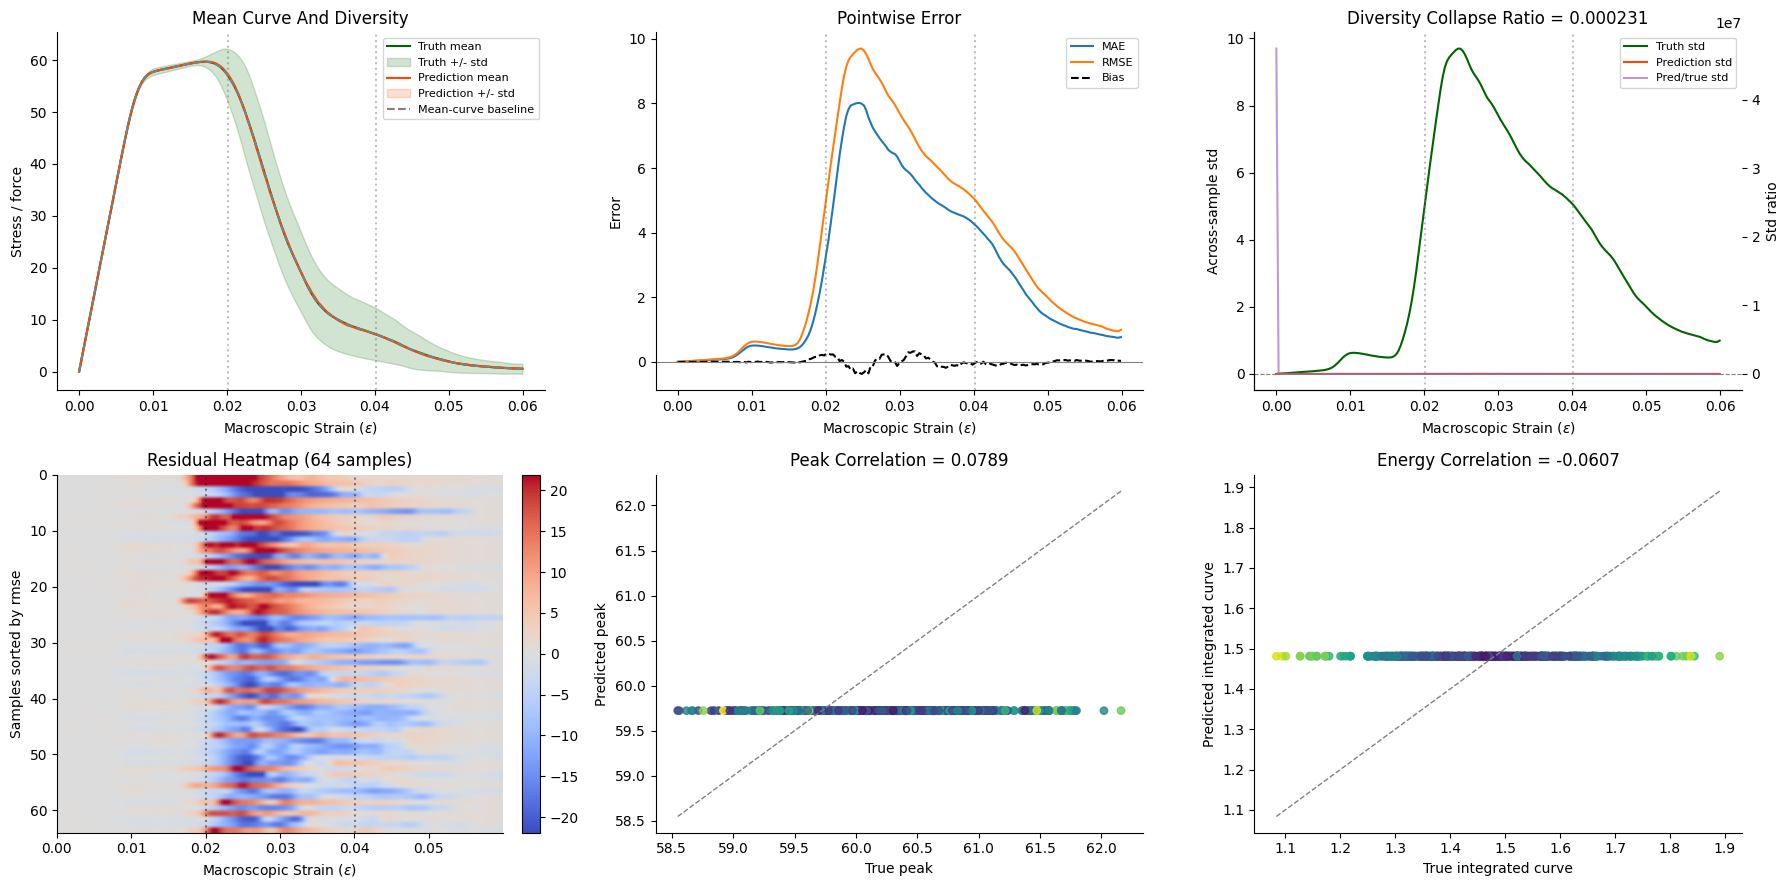

In [11]:
if active_diag is not None:
    plot_curve_diagnostics(
        getattr(DAT, f"{active_key[0]}_OUT_df", None) if DAT is not None else None,
        active_diag["y_pred"],
        active_diag["y_true"],
        diagnostics=active_diag,
        mode=active_key[0].lower(),
        max_samples=MAX_SAMPLES_PLOT,
        sort_by="rmse",
    )

## 10. Prediction Collapse And Pointwise Error

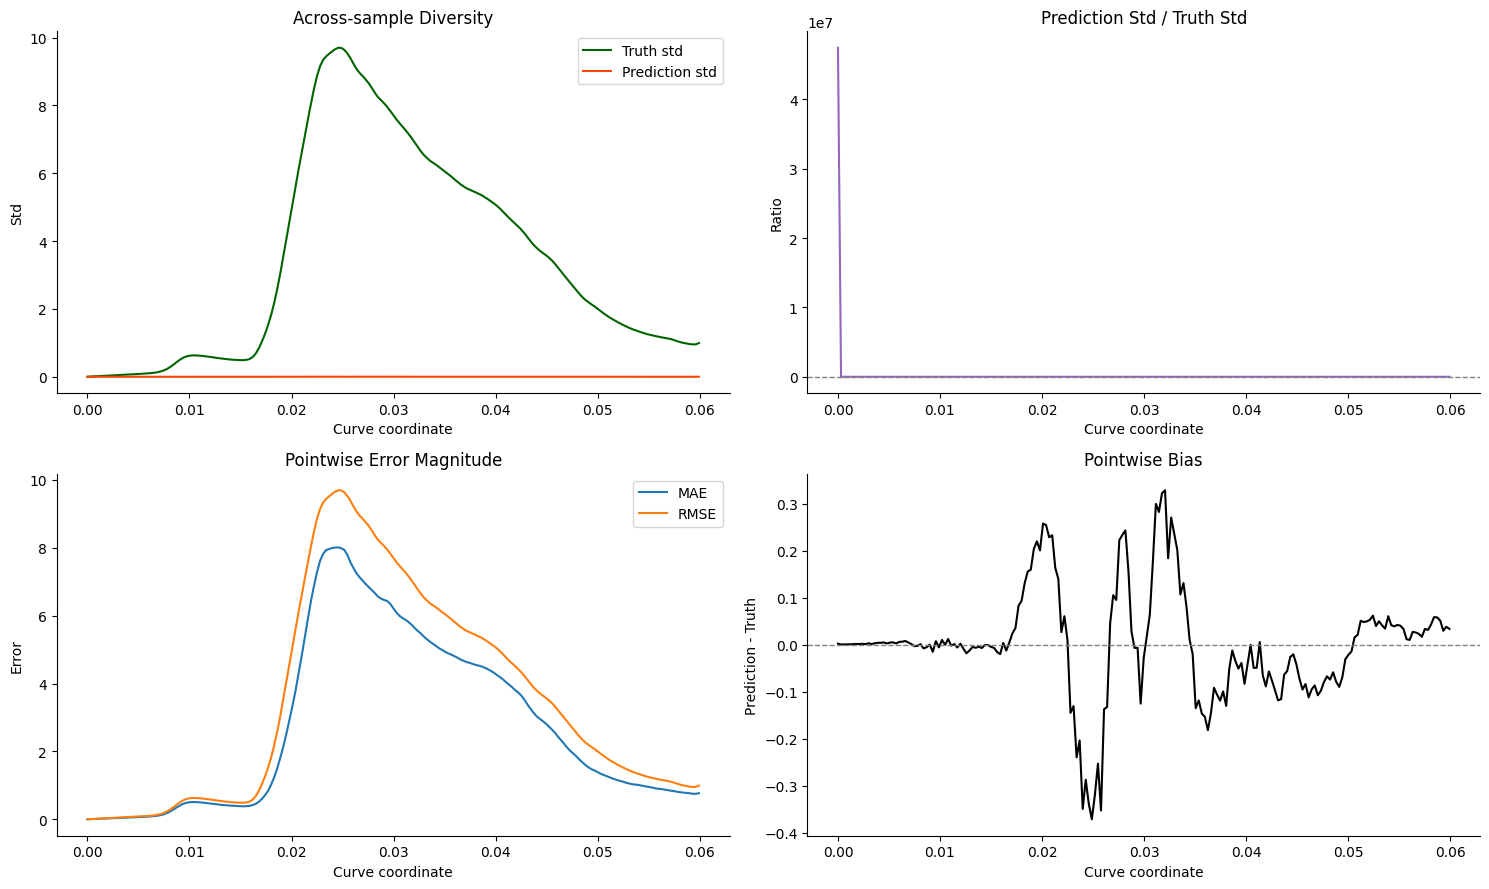

In [12]:
if active_diag is not None:
    point = active_diag["point_metrics"]
    x = active_diag["x"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    axes[0, 0].plot(x, point["true_std"], label="Truth std", color="darkgreen")
    axes[0, 0].plot(x, point["pred_std"], label="Prediction std", color="orangered")
    axes[0, 0].set_title("Across-sample Diversity")
    axes[0, 0].set_xlabel("Curve coordinate")
    axes[0, 0].set_ylabel("Std")
    axes[0, 0].legend()

    axes[0, 1].plot(x, point["std_ratio"], color="tab:purple")
    axes[0, 1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Prediction Std / Truth Std")
    axes[0, 1].set_xlabel("Curve coordinate")
    axes[0, 1].set_ylabel("Ratio")

    axes[1, 0].plot(x, point["mae"], label="MAE")
    axes[1, 0].plot(x, point["rmse"], label="RMSE")
    axes[1, 0].set_title("Pointwise Error Magnitude")
    axes[1, 0].set_xlabel("Curve coordinate")
    axes[1, 0].set_ylabel("Error")
    axes[1, 0].legend()

    axes[1, 1].plot(x, point["bias"], color="black")
    axes[1, 1].axhline(0.0, color="gray", linestyle="--", linewidth=1)
    axes[1, 1].set_title("Pointwise Bias")
    axes[1, 1].set_xlabel("Curve coordinate")
    axes[1, 1].set_ylabel("Prediction - Truth")

    fig.tight_layout()
    plt.show()

## 11. Error Curves And Diagnostic Correlations

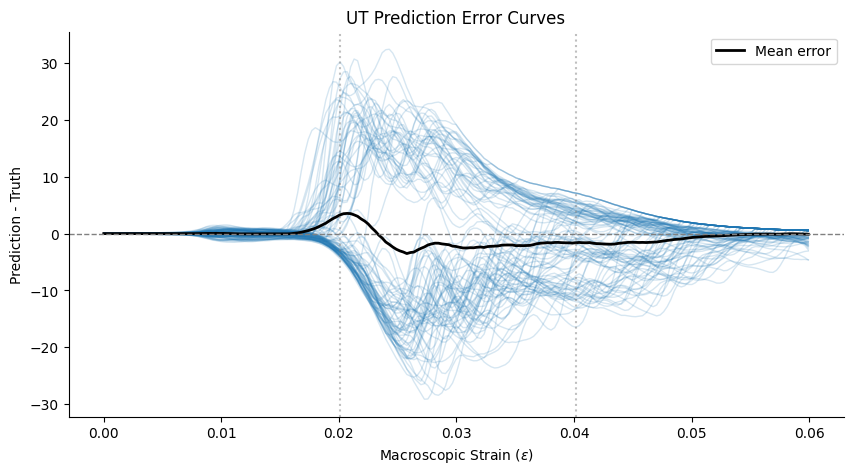

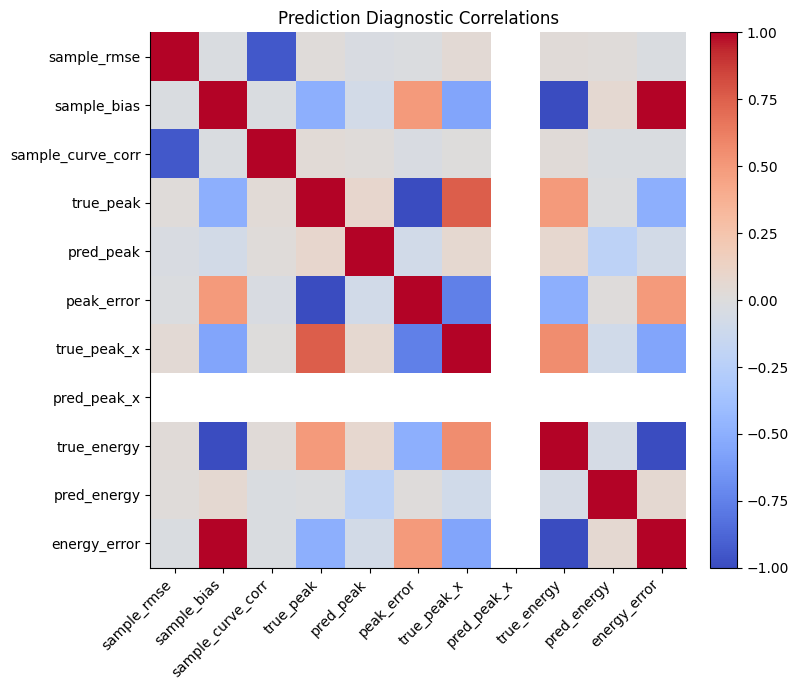

,sample_rmse,sample_bias,sample_curve_corr,true_peak,pred_peak,peak_error,true_peak_x,pred_peak_x,true_energy,pred_energy,energy_error
sample_rmse,1.000000,-0.025600,-0.944922,0.022182,-0.038236,-0.022210,0.046041,NaN,0.025569,0.018670,-0.025568
sample_bias,-0.025600,1.000000,-0.028791,-0.493506,-0.075406,0.493480,-0.555845,NaN,-1.000000,0.060806,1.000000
sample_curve_corr,-0.944922,-0.028791,1.000000,0.033092,0.016098,-0.033082,0.006235,NaN,0.028822,-0.028344,-0.028824
true_peak,0.022182,-0.493506,0.033092,1.000000,0.078866,-1.000000,0.757702,NaN,0.493633,-0.011806,-0.493632
pred_peak,-0.038236,-0.075406,0.016098,0.078866,1.000000,-0.078162,0.064968,NaN,0.075363,-0.214308,-0.075375
peak_error,-0.022210,0.493480,-0.033082,-1.000000,-0.078162,1.000000,-0.757698,NaN,-0.493607,0.011655,0.493606
true_peak_x,0.046041,-0.555845,0.006235,0.757702,0.064968,-0.757698,1.000000,NaN,0.555932,-0.089009,-0.555936
pred_peak_x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
true_energy,0.025569,-1.000000,0.028822,0.493633,0.075363,-0.493607,0.555932,NaN,1.000000,-0.060726,-1.000000
pred_energy,0.018670,0.060806,-0.028344,-0.011806,-0.214308,0.011655,-0.089009,NaN,-0.060726,1.000000,0.060787


In [14]:
if active_diag is not None:
    plot_prediction_error_curves(
        getattr(DAT, f"{active_key[0]}_OUT_df", None) if DAT is not None else None,
        active_diag["y_pred"],
        active_diag["y_true"],
        diagnostics=active_diag,
        mode=active_key[0].lower(),
        max_samples=ERROR_CURVE_SAMPLES,
        sort_by="rmse",
    )

    corr, fig, ax = plot_curve_correlation_matrix(active_diag, method="pearson")
    display(corr)

## 12. Sample-Level Metric Distributions

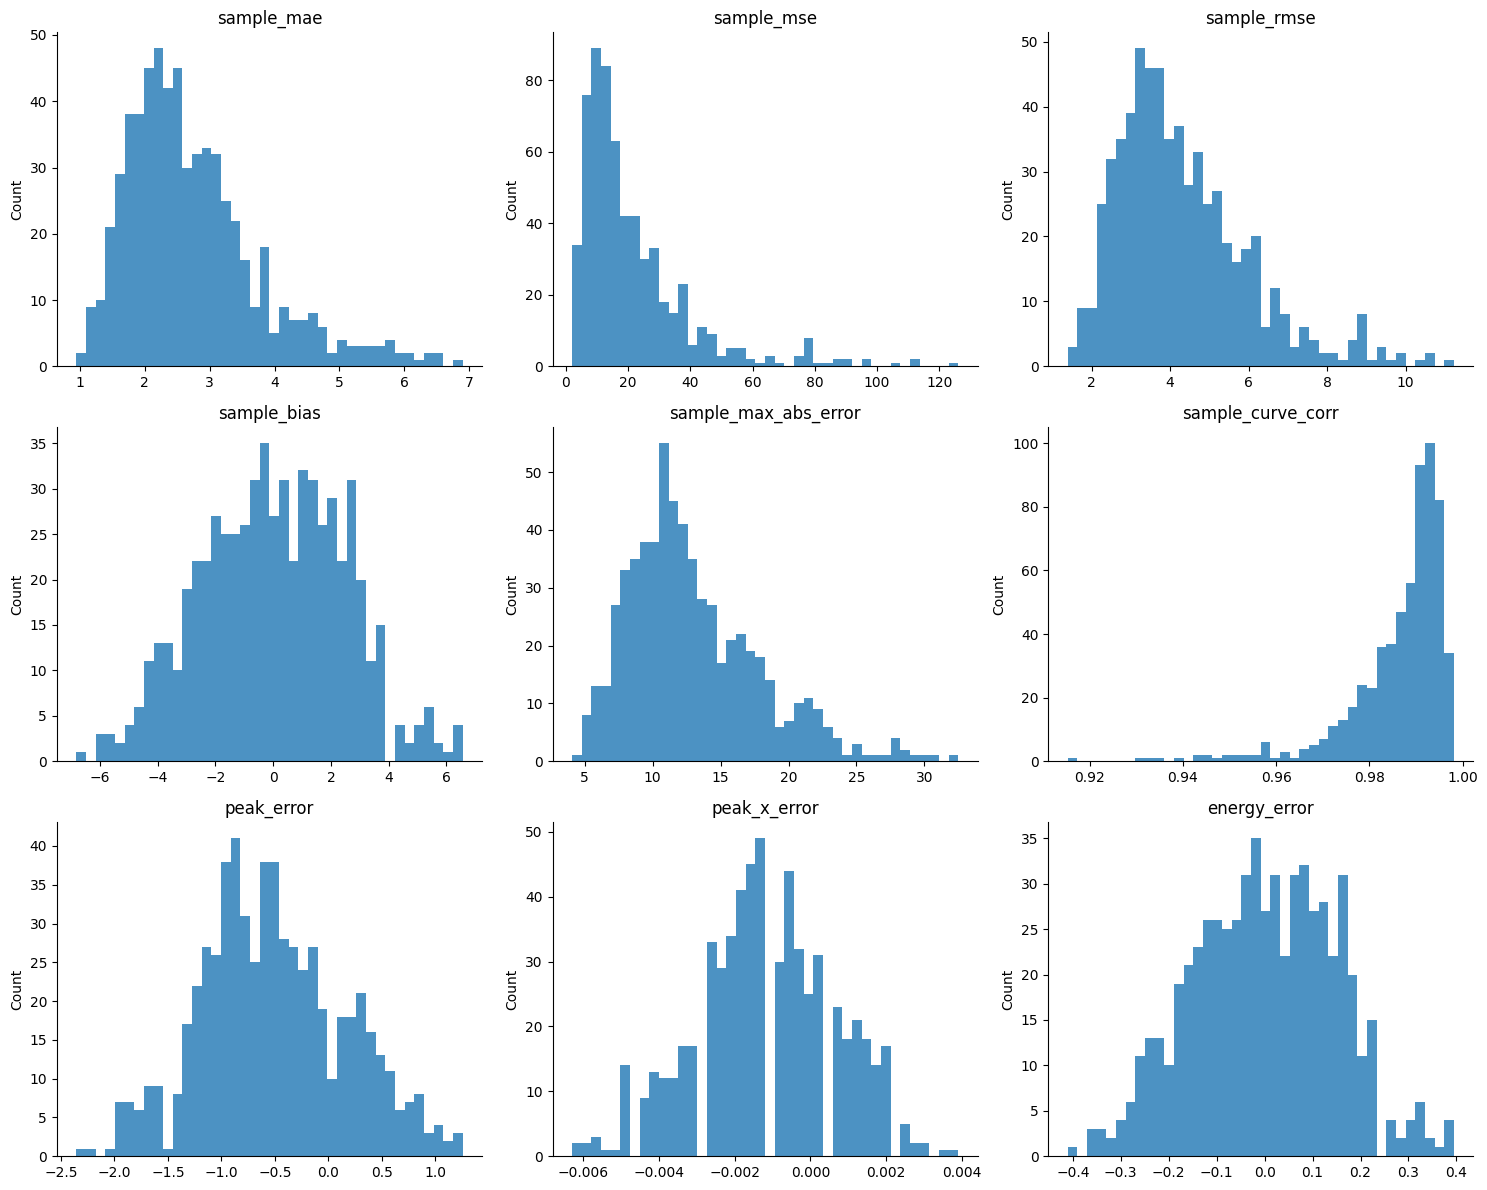

,count,mean,std,min,25%,50%,75%,max
sample_mae,618.0,2.750544,1.052893,0.944368,2.005450,2.525034,3.229746,6.897877
sample_mse,618.0,21.451343,18.254139,1.935583,9.762119,15.864924,27.047573,126.116066
sample_rmse,618.0,4.314889,1.684537,1.391252,3.124437,3.983080,5.200728,11.230141
sample_bias,618.0,-0.015134,2.475102,-6.827094,-1.808361,0.044034,1.848776,6.565446
sample_max_abs_error,618.0,12.963195,4.882544,4.059278,9.471551,11.911656,15.675470,32.493833
sample_curve_corr,618.0,0.986333,0.010808,0.915262,0.983041,0.989861,0.993035,0.998172
peak_error,618.0,-0.514506,0.670728,-2.356665,-0.965203,-0.566042,-0.075824,1.254770
peak_x_error,618.0,-0.001167,0.001837,-0.006291,-0.002400,-0.001200,0.000000,0.003900
energy_error,618.0,-0.000907,0.148838,-0.410917,-0.108681,0.002761,0.111235,0.394954


In [39]:
if active_diag is not None:
    samples = active_diag["sample_metrics"]
    numeric_cols = [
        "sample_mae",
        "sample_mse",
        "sample_rmse",
        "sample_bias",
        "sample_max_abs_error",
        "sample_curve_corr",
        "peak_error",
        "peak_x_error",
        "energy_error",
    ]
    numeric_cols = [col for col in numeric_cols if col in samples.columns]

    ncols = 3
    nrows = int(np.ceil(len(numeric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, col in zip(axes, numeric_cols):
        ax.hist(samples[col].dropna(), bins=40, color="tab:blue", alpha=0.8)
        ax.set_title(col)
        ax.set_ylabel("Count")
    for ax in axes[len(numeric_cols):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

    display(samples[numeric_cols].describe().T)

## 13. Peak And Energy Agreement

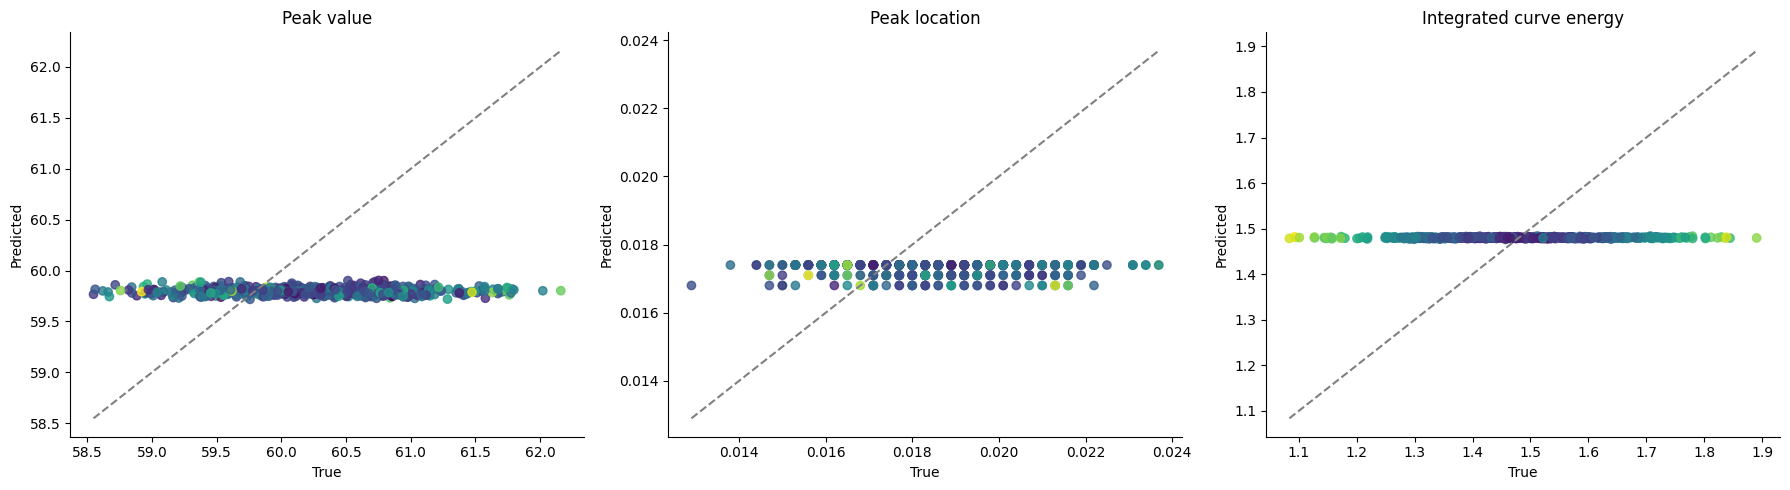

In [40]:
if active_diag is not None:
    samples = active_diag["sample_metrics"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(samples["true_peak"], samples["pred_peak"], c=samples["sample_rmse"], cmap="viridis", alpha=0.8)
    lo = np.nanmin([samples["true_peak"].min(), samples["pred_peak"].min()])
    hi = np.nanmax([samples["true_peak"].max(), samples["pred_peak"].max()])
    axes[0].plot([lo, hi], [lo, hi], color="gray", linestyle="--")
    axes[0].set_title("Peak value")
    axes[0].set_xlabel("True")
    axes[0].set_ylabel("Predicted")

    axes[1].scatter(samples["true_peak_x"], samples["pred_peak_x"], c=samples["sample_rmse"], cmap="viridis", alpha=0.8)
    lo = np.nanmin([samples["true_peak_x"].min(), samples["pred_peak_x"].min()])
    hi = np.nanmax([samples["true_peak_x"].max(), samples["pred_peak_x"].max()])
    axes[1].plot([lo, hi], [lo, hi], color="gray", linestyle="--")
    axes[1].set_title("Peak location")
    axes[1].set_xlabel("True")
    axes[1].set_ylabel("Predicted")

    axes[2].scatter(samples["true_energy"], samples["pred_energy"], c=samples["sample_rmse"], cmap="viridis", alpha=0.8)
    lo = np.nanmin([samples["true_energy"].min(), samples["pred_energy"].min()])
    hi = np.nanmax([samples["true_energy"].max(), samples["pred_energy"].max()])
    axes[2].plot([lo, hi], [lo, hi], color="gray", linestyle="--")
    axes[2].set_title("Integrated curve energy")
    axes[2].set_xlabel("True")
    axes[2].set_ylabel("Predicted")

    fig.tight_layout()
    plt.show()

## 14. Zone Metrics

,zone,start_idx,end_idx,x_start,x_end,mae,mse,rmse,bias,true_std_mean,pred_std_mean,collapse_ratio
0,elastic,0,67,0.000000,0.019799,0.442747,1.328131,1.152446,0.027969,0.658396,0.015011,0.022800
1,peak_region,67,134,0.020099,0.039848,5.914535,55.510688,7.450549,-0.085123,7.303085,0.099176,0.013580
2,post_peak,134,201,0.040147,0.059936,1.894351,7.515209,2.741388,0.011752,2.417972,0.050217,0.020768


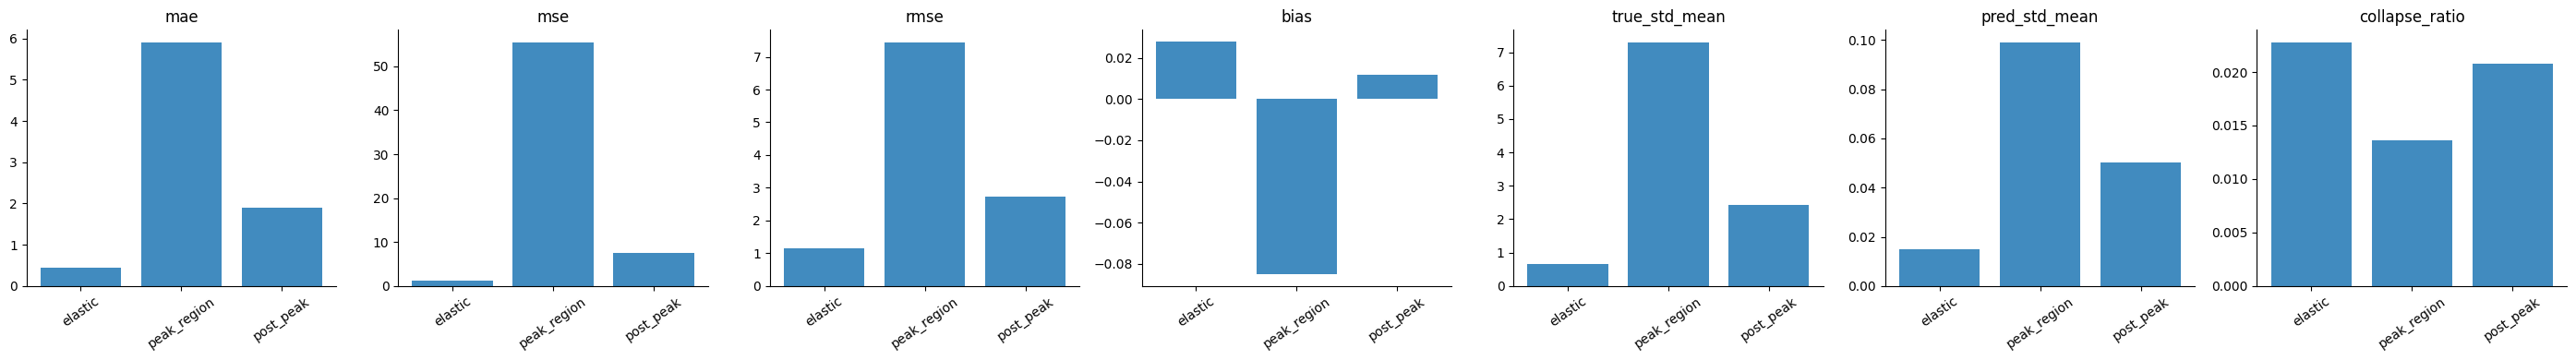

In [41]:
if active_diag is not None:
    zone = active_diag["zone_metrics"].copy()
    display(zone)

    zone_cols = ["mae", "mse", "rmse", "bias", "true_std_mean", "pred_std_mean", "collapse_ratio"]
    zone_cols = [col for col in zone_cols if col in zone.columns]
    fig, axes = plt.subplots(1, len(zone_cols), figsize=(4 * len(zone_cols), 4), sharex=False)
    axes = np.asarray(axes).reshape(-1)
    for ax, col in zip(axes, zone_cols):
        ax.bar(zone["zone"], zone[col], color="tab:blue", alpha=0.85)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    plt.show()

## 15. Best, Worst, Selected, And Random Curves

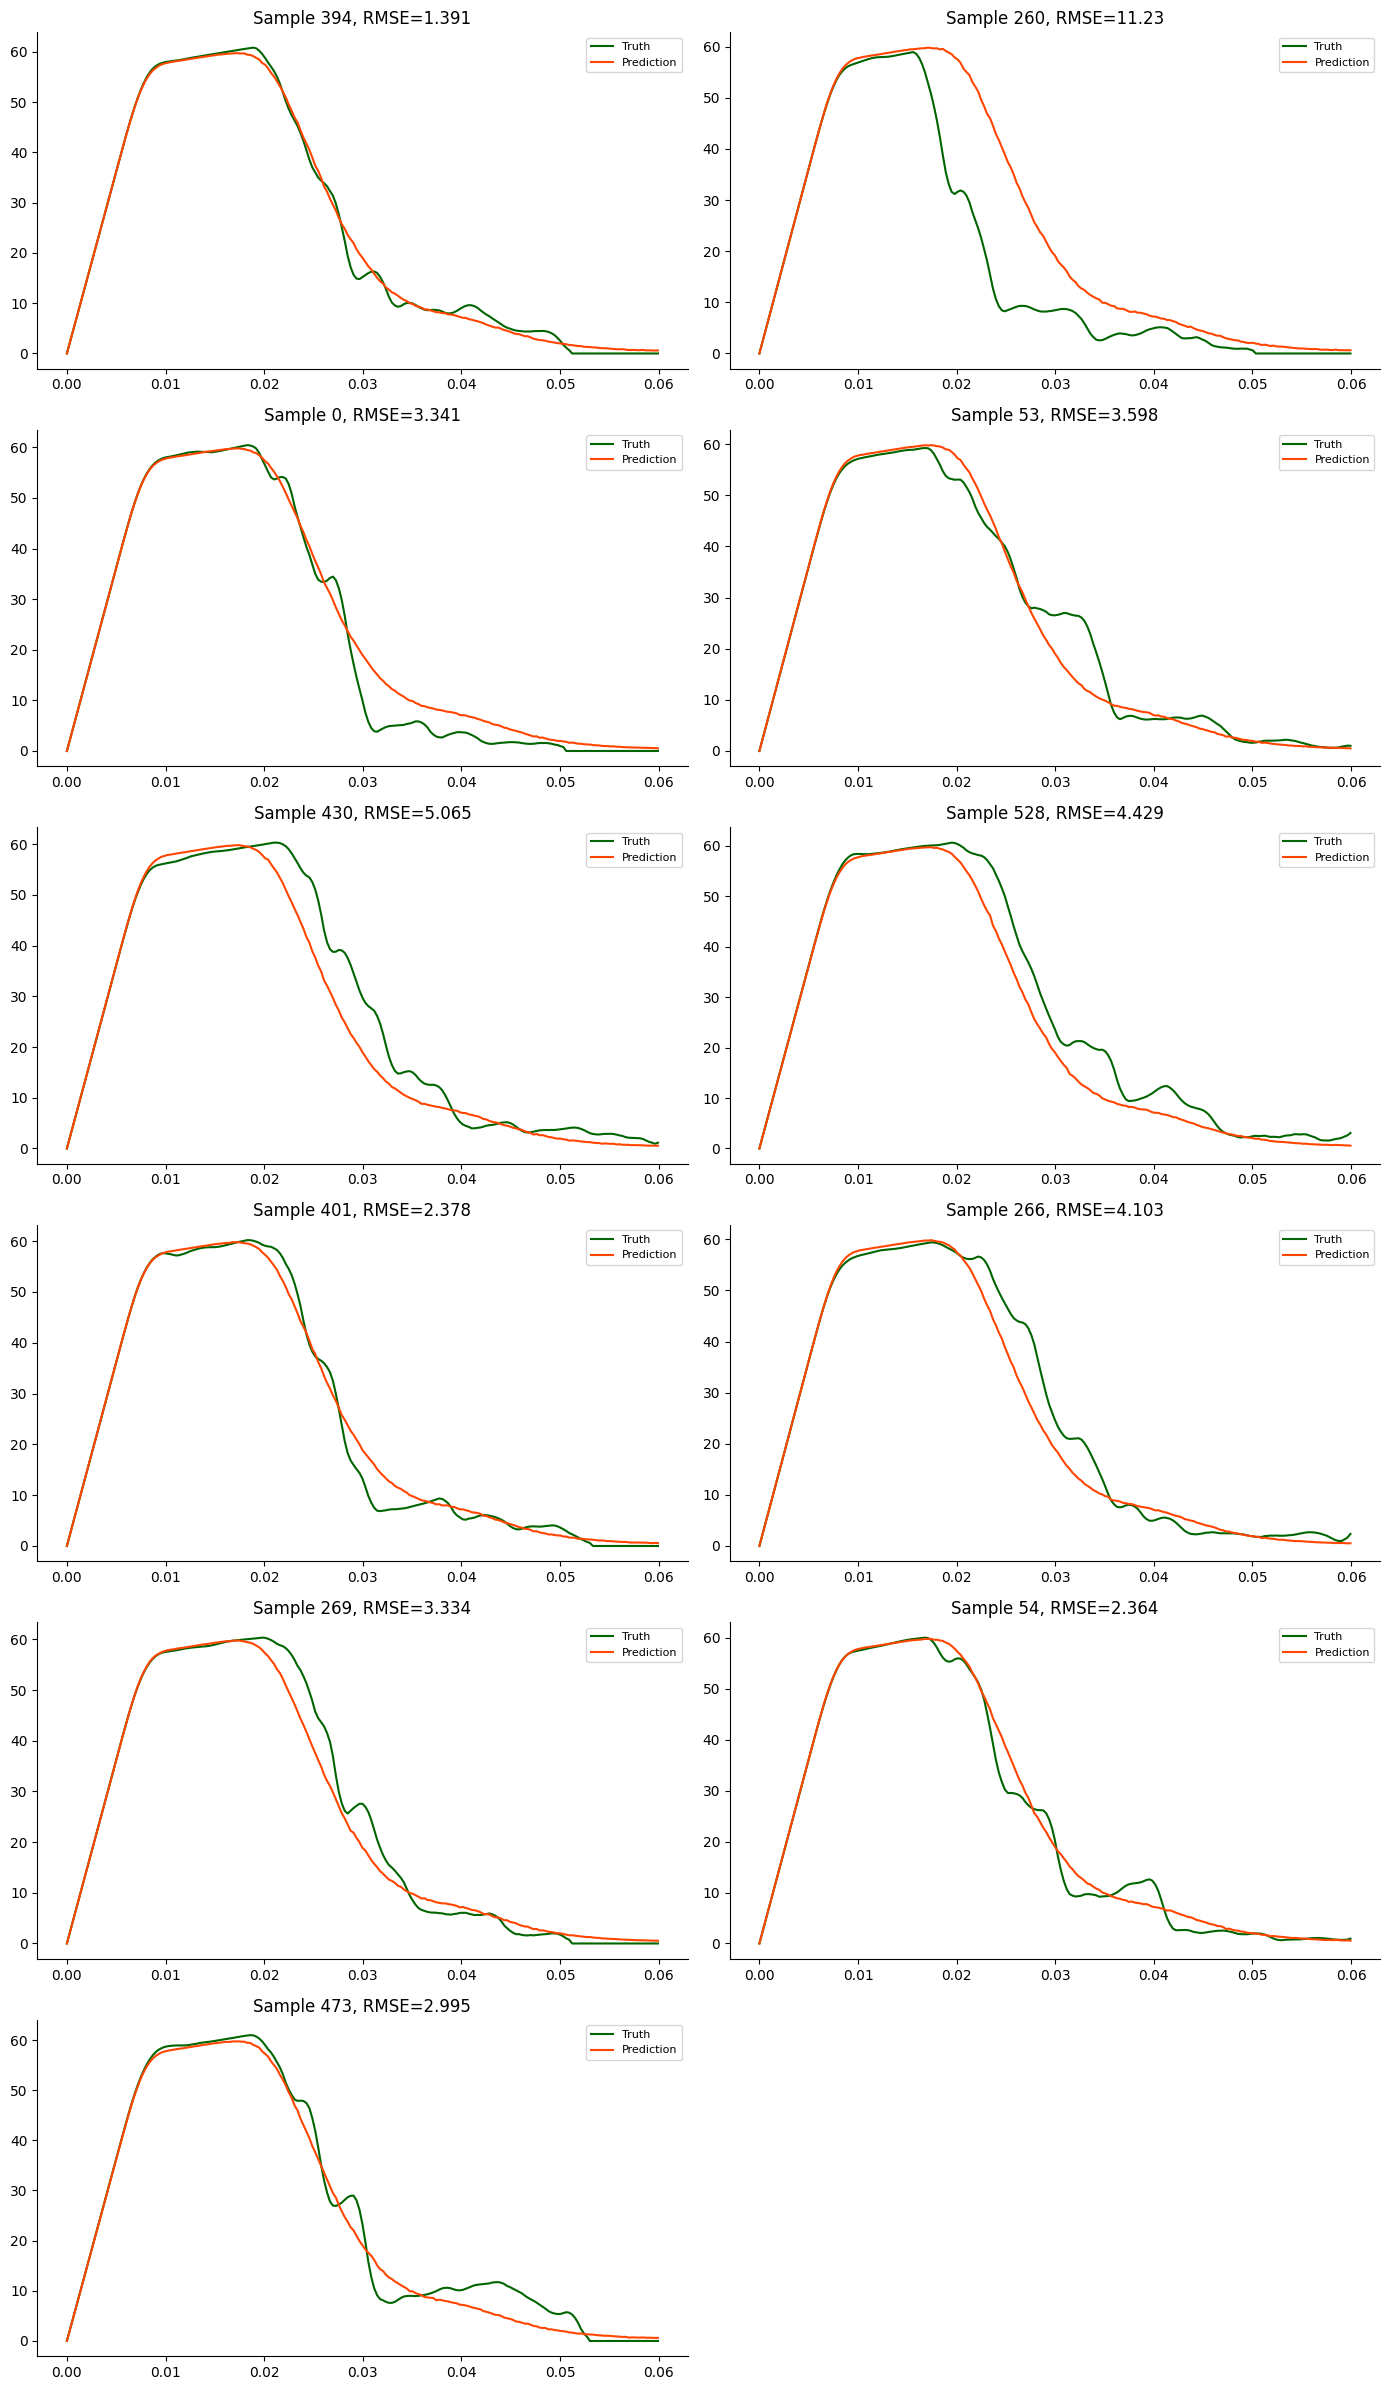

In [42]:
if active_diag is not None:
    samples = active_diag["sample_metrics"]
    y_pred = active_diag["y_pred"]
    y_true = active_diag["y_true"]
    x = active_diag["x"]
    candidate_indices = []
    if "sample_rmse" in samples.columns:
        candidate_indices.extend(samples.sort_values("sample_rmse").head(1)["sample"].astype(int).tolist())
        candidate_indices.extend(samples.sort_values("sample_rmse").tail(1)["sample"].astype(int).tolist())
    candidate_indices.append(int(SELECTED_SAMPLE))
    rng = np.random.default_rng(42)
    if len(samples) > 0:
        candidate_indices.extend(rng.choice(samples["sample"].astype(int), size=min(RANDOM_SAMPLE_COUNT, len(samples)), replace=False).tolist())
    candidate_indices = [idx for idx in dict.fromkeys(candidate_indices) if 0 <= idx < len(y_pred)]

    ncols = 2
    nrows = int(np.ceil(len(candidate_indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, idx in zip(axes, candidate_indices):
        ax.plot(x, y_true[idx], color="darkgreen", label="Truth")
        ax.plot(x, y_pred[idx], color="orangered", label="Prediction")
        row = samples.loc[samples["sample"].astype(int) == int(idx)]
        rmse_text = f", RMSE={row['sample_rmse'].iloc[0]:.4g}" if not row.empty and "sample_rmse" in row else ""
        ax.set_title(f"Sample {idx}{rmse_text}")
        ax.legend(fontsize=8)
    for ax in axes[len(candidate_indices):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

## 16. Loss Component Breakdown

For losses such as `CombinedCurveLoss`, this evaluates the available loss components on the saved predictions and truth arrays. This is a diagnostic calculation only; it does not train or update the model.

In [43]:
loss_rows = []
if MOD is not None and active_diag is not None:
    mode = active_key[0]
    y_pred_t = torch.as_tensor(active_diag["y_pred"], dtype=torch.float32, device=MOD.device)
    y_true_t = torch.as_tensor(active_diag["y_true"], dtype=torch.float32, device=MOD.device)
    for loss_idx, loss_obj in enumerate(getattr(MOD, f"{mode}_losses", [])):
        if not hasattr(loss_obj, "component_losses"):
            loss_rows.append({"loss_index": loss_idx, "loss_class": loss_obj.__class__.__name__, "component": "total", "value": np.nan, "note": "component_losses unavailable"})
            continue
        try:
            with torch.no_grad():
                components = loss_obj.component_losses(y_pred_t, y_true_t, weighted=False)
                weighted_components = loss_obj.component_losses(y_pred_t, y_true_t, weighted=True)
            for comp_name, comp_value in components.items():
                value = comp_value.detach().cpu().item() if torch.is_tensor(comp_value) else float(comp_value)
                weighted_value = weighted_components.get(comp_name, np.nan)
                weighted_value = weighted_value.detach().cpu().item() if torch.is_tensor(weighted_value) else float(weighted_value)
                loss_rows.append({"loss_index": loss_idx, "loss_class": loss_obj.__class__.__name__, "component": comp_name, "value": value, "weighted_value": weighted_value})
        except Exception as exc:
            loss_rows.append({"loss_index": loss_idx, "loss_class": loss_obj.__class__.__name__, "component": "error", "value": np.nan, "note": repr(exc)})

loss_components_df = pd.DataFrame(loss_rows)
display(loss_components_df)

if not loss_components_df.empty and "weighted_value" in loss_components_df.columns:
    plot_df = loss_components_df.dropna(subset=["weighted_value"])
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(plot_df["component"], plot_df["weighted_value"], color="tab:blue")
        ax.set_title("Weighted Loss Components")
        ax.tick_params(axis="x", rotation=35)
        fig.tight_layout()
        plt.show()
elif MOD is None:
    print("MODEL is not loaded, so loss components cannot be evaluated.")

,loss_index,loss_class,component,value,note
0,0,MSELoss,total,NaN,component_losses unavailable


## 17. Optional Activation Diagnostics

This requires a forward pass through the loaded model and dataloader. It is off by default.

In [44]:
if RUN_ACTIVATION_DIAGNOSTICS:
    if MOD is None or ACTIVE_MODE is None or ACTIVE_SPLIT is None:
        print("Activation diagnostics require a loaded MODEL and active mode/split.")
    else:
        activation_summary = MOD.activation_diagnostics(
            mode=ACTIVE_MODE,
            split=ACTIVE_SPLIT,
            max_batches=1,
            plot=True,
        )
        display(activation_summary)
else:
    print("Activation diagnostics skipped. Set RUN_ACTIVATION_DIAGNOSTICS = True to enable.")

Activation diagnostics skipped. Set RUN_ACTIVATION_DIAGNOSTICS = True to enable.


## 18. Optional Prediction Recompute

This is intentionally disabled by default. Enable only when saved prediction arrays are missing and you want to run the loaded model locally.

In [45]:
if RECOMPUTE_MISSING_PREDICTIONS_WITH_MODEL:
    if USE_SAVED_RESULTS_ONLY:
        print("Skipped because USE_SAVED_RESULTS_ONLY = True.")
    elif MOD is None:
        print("Skipped because MODEL is not loaded.")
    elif ACTIVE_SPLIT is None:
        print("Skipped because ACTIVE_SPLIT is not set.")
    else:
        recomputed = MOD.evaluate_split(
            split=ACTIVE_SPLIT,
            mode=ACTIVE_MODE,
            plot=False,
            diagnostics=True,
            diag_plot=False,
            zone_boundaries=ZONE_BOUNDARIES,
        )
        print("Recomputed predictions in memory. Existing results files were not overwritten.")
else:
    print("Prediction recompute skipped.")

Prediction recompute skipped.


## 19. Save Figures

In [ ]:
if SAVE_FIGURES:
    prefix = ""
    if ACTIVE_MODE and ACTIVE_SPLIT:
        prefix = f"{str(ACTIVE_MODE).upper()}_{str(ACTIVE_SPLIT).lower()}"
    saved_figures = postprocess_save_open_figures(
        POST_DIR,
        prefix=prefix,
        formats=("png",),
        dpi=250,
        close=False,
    )
    print(f"Saved {len(saved_figures)} figure file(s) to {POST_DIR}")
    for path in saved_figures:
        print(" -", path)
else:
    print("Figure saving skipped.")

Saved 0 figure file(s) to Z:\p2\UT\MLP\HPO\MLP_full_hOpt\best_model_results\postProcessing


: 